## Preprocessing

In [ ]:
#libraries
#encoding
import pandas as pd
import numpy as np
#plotting
import matplotlib.pyplot as plt
import umap.umap_ as umap
#preprocess
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
#models
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
#feature selection
from sklearn.feature_selection import mutual_info_classif
#metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
#plots
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#silence warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#new code for raw files
import pandas as pd

def read_raw(filepath):
    df = pd.read_csv(filepath, sep=r'\s+', header=0)

    # Separate metadata and SNPs
    meta = df.iloc[:, :6]
    X = df.iloc[:, 6:]   # genotype matrix
    y = meta["FID"]
    return X,y



In [ ]:
#split raw
def split(X,y):
    from sklearn.model_selection import train_test_split
    # Step 1: Train + Temp (val+test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.3,
        stratify=y,
        random_state=42
    )

    # Step 2: Split temp into val (10%) and test (20%)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=2/3,  # 20% test, 10% val overall
        stratify=y_temp,
        random_state=42
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
from sklearn.preprocessing import LabelEncoder
import umap.umap_ as umap_lib # Changed alias to avoid conflict with function name
import matplotlib.pyplot as plt # Added import as plt is called
import numpy as np # Added import as np is called

def umap(
    X,
    breeds, # Renamed from labels to breeds to make it clear it's the raw labels
    metrics=("euclidean", "cosine", "hamming"), # Added default values
    n_neighbors=15,
    min_dist=0.1,
    random_state=42,
    figsize=(16, 5),
    dpi=200
):
    # -------------------------
    # Encode breed labels (new step for this function)
    # -------------------------
    encoder = LabelEncoder()
    labels = encoder.fit_transform(breeds)
    label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

    # -------------------------
    # 4. Prepare plotting
    # -------------------------
    unique_labels = np.unique(labels)
    int_to_name = {v: k for k, v in label_mapping.items()}

    fig, axes = plt.subplots(
        1, len(metrics), figsize=figsize, dpi=dpi, squeeze=False
    )
    axes = axes[0]

    cmap = plt.get_cmap("tab10")

    # -------------------------
    # 5. UMAP for each metric
    # -------------------------
    for ax, metric in zip(axes, metrics):
        reducer = umap_lib.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric=metric,
            random_state=random_state
        )

        embedding = reducer.fit_transform(X)

        for i, lab in enumerate(unique_labels):
            mask = labels == lab
            ax.scatter(
                embedding[mask, 0],
                embedding[mask, 1],
                s=25,
                alpha=0.85,
                color=cmap(i % 10),
                label=int_to_name[lab],
                edgecolors="black",
                linewidths=0.2
            )

        ax.set_title(f"UMAP ({metric.capitalize()})", fontsize=14)
        ax.set_xlabel("UMAP-1")
        ax.set_ylabel("UMAP-2")
        ax.grid(False)

    # -------------------------
    # 6. Shared legend
    # -------------------------
    handles, labels_leg = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels_leg,
        title="Breed",
        loc="center right",
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()

    return X, labels, label_mapping

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00


## output

In [ ]:
#import drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
X_raw,y =read_raw("/content/drive/MyDrive/merged_out_raw.raw")

# Calculate and print NA values as percentage before filling
na_percentage_before = (X_raw.isna().sum().sum() / X_raw.size) * 100
print(f"Percentage of NA values before filling: {na_percentage_before:.2f}%")

# Fill NaN values with -1 to treat them as a distinct category
X = X_raw.fillna(-1)

# Verify that there are no more NA values
na_percentage_after = (X.isna().sum().sum() / X.size) * 100
print(f"Percentage of NA values after filling with -1: {na_percentage_after:.2f}%")


Percentage of NA values before filling: 2.74%
Percentage of NA values after filling with -1: 0.00%


In [ ]:
#print the no. of samples per breed
breed_counts = y.value_counts()
print(breed_counts)

FID
Brahman      79
Nelore       60
Gir          59
Holstein     46
Sahiwal      32
Hereford     22
Ongole       20
Jersey       13
Tharpakar    13
Name: count, dtype: int64


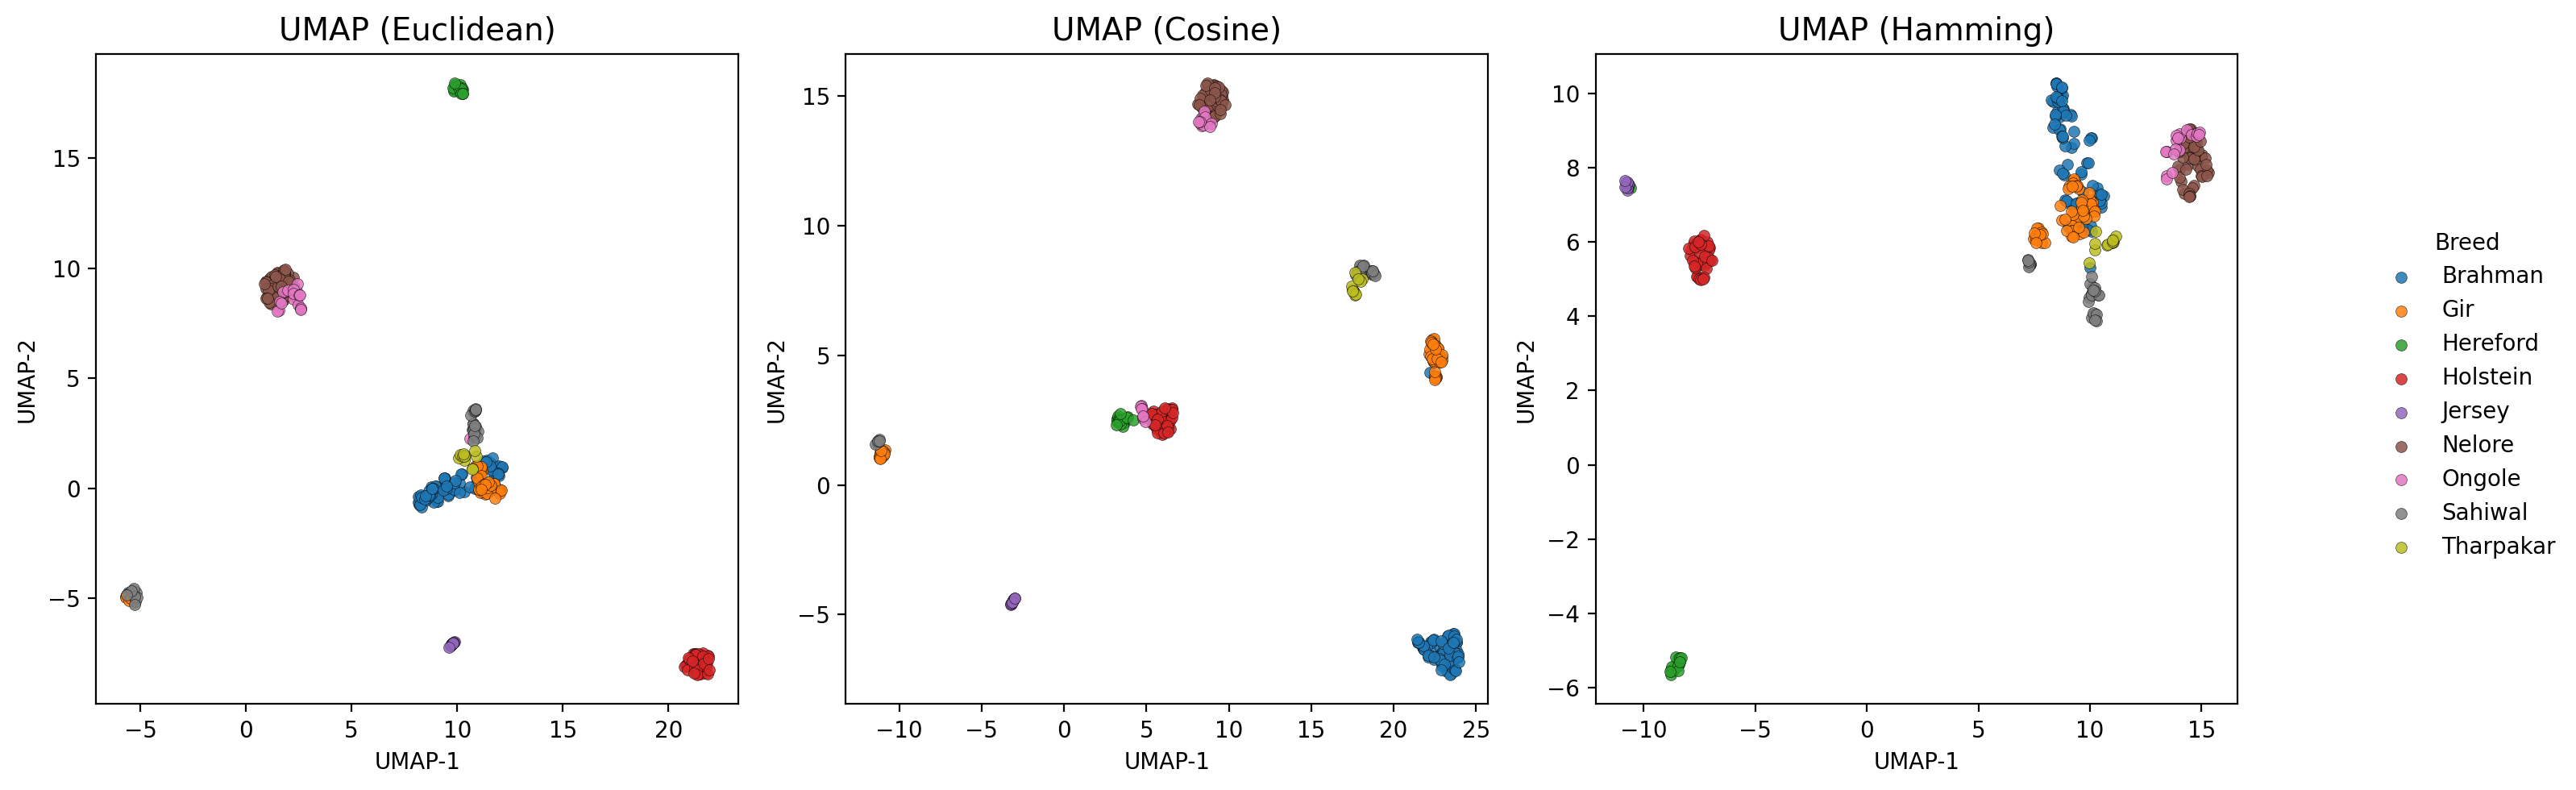

In [ ]:
df_snps_raw, labels_raw, label_mapping_raw = umap(X,y)

In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test= split(X,y)

## optuna new

In [ ]:
import optuna
import numpy as np
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score

# Assume you already created:
# X_train, y_train, X_val, y_val

def train_val_evaluation(X_train, y_train, X_val, y_val, C):

    # Get global classes from FULL data (important for multiclass AUC consistency)
    all_classes = np.unique(np.concatenate([y_train, y_val]))
    n_total_classes = len(all_classes)

    # Pipeline
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=C,
            max_iter=5000
        ))
    ])

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)

    # Probabilities for trained classes
    y_prob_trained = model.predict_proba(X_val)
    trained_classes = model.classes_

    # Build full probability matrix
    y_prob_full = np.zeros((X_val.shape[0], n_total_classes))

    for i, cls in enumerate(trained_classes):
        global_idx = np.where(all_classes == cls)[0][0]
        y_prob_full[:, global_idx] = y_prob_trained[:, i]

    # Binarize validation labels
    y_val_bin = label_binarize(y_val, classes=all_classes)

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val_bin, y_prob_full, multi_class='ovr')

    return acc, auc


def objective(trial):
    C = trial.suggest_float("C", 1e-4, 10, log=True)

    acc, auc = train_val_evaluation(
        X_train, y_train,
        X_val, y_val,
        C=C
    )

    return auc  # maximize validation AUC


# Study
study = optuna.create_study(
    direction="maximize",
    storage="sqlite:///study.db",
    study_name="logistic_regression_train_val",
    load_if_exists=True
)

study.optimize(objective, n_trials=50)

print("Best params:", study.best_params)
print("Best AUC:", study.best_value)


[I 2026-04-26 09:45:10,989] A new study created in RDB with name: logistic_regression_train_val
[I 2026-04-26 09:45:13,842] Trial 0 finished with value: 0.5 and parameters: {'C': 0.0004025444909946075}. Best is trial 0 with value: 0.5.
[I 2026-04-26 09:45:21,220] Trial 1 finished with value: 0.9974825055470217 and parameters: {'C': 2.1109121724709015}. Best is trial 1 with value: 0.9974825055470217.
[I 2026-04-26 09:45:24,415] Trial 2 finished with value: 0.5 and parameters: {'C': 0.0017975131639285167}. Best is trial 1 with value: 0.9974825055470217.
[I 2026-04-26 09:45:26,505] Trial 3 finished with value: 0.5 and parameters: {'C': 0.001025509718018376}. Best is trial 1 with value: 0.9974825055470217.
[I 2026-04-26 09:45:28,682] Trial 4 finished with value: 0.5 and parameters: {'C': 0.0009726011572364193}. Best is trial 1 with value: 0.9974825055470217.
[I 2026-04-26 09:45:33,231] Trial 5 finished with value: 0.9856082910518396 and parameters: {'C': 0.05623295980063303}. Best is trial

Best params: {'C': 9.612191613291031}
Best AUC: 1.0


In [ ]:
#optuna dashboard
!pip install optuna-dashboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 8.7 MB/s eta 0:00:00


In [ ]:
#use optuna dashboard
from optuna.visualization import plot_optimization_history
plot_optimization_history(study)

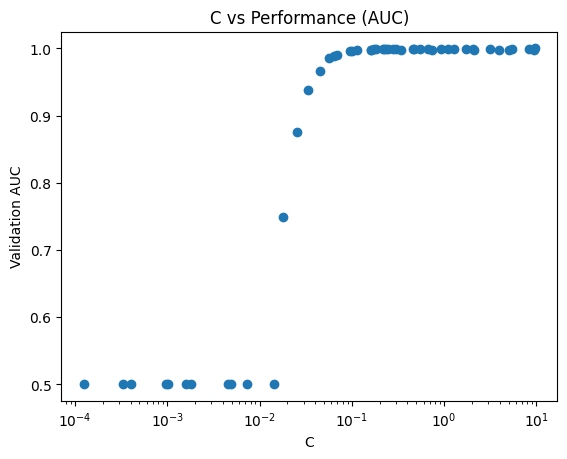

In [ ]:
import matplotlib.pyplot as plt

Cs = [t.params["C"] for t in study.trials]
scores = [t.value for t in study.trials]

plt.scatter(Cs, scores)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Validation AUC")
plt.title("C vs Performance (AUC)")
plt.show()

[I 2026-04-26 11:52:11,049] Using an existing study with name 'logistic_regression_train_val' instead of creating a new one.


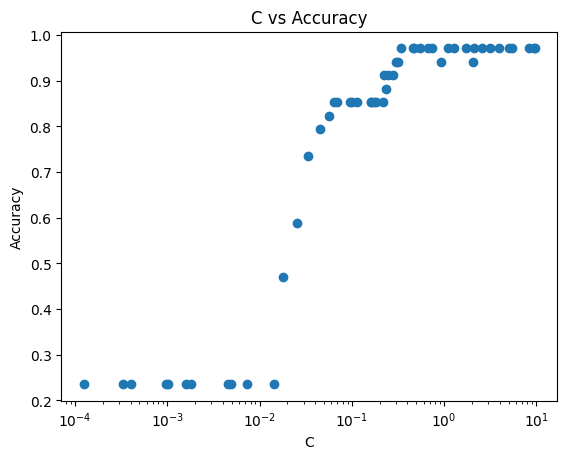

In [ ]:
# C vs Accuracy Plot
import matplotlib.pyplot as plt

Cs = []
accuracies = []
study = optuna.create_study(
    direction="maximize",
    storage="sqlite:///study.db",
    study_name="logistic_regression_train_val", # This is where you set the name
    load_if_exists=True
)

# Iterate through each trial in the study to get C and re-evaluate accuracy
for trial in study.trials:
    if "C" in trial.params:
        current_C = trial.params["C"]
        # Re-run evaluation to get accuracy, as it might not be stored in user_attrs
        acc, _ = train_val_evaluation(
            X_train, y_train,
            X_val, y_val,
            C=current_C
        )
        Cs.append(current_C)
        accuracies.append(acc)

plt.scatter(Cs, accuracies)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("C vs Accuracy")
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold

def l1_logistic_cv(X, y, best_C, n_splits=10):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracies = []
    aucs = []

    # Get global classes for consistent AUC calculation
    all_classes = np.unique(y)

    for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=best_C,
                max_iter=5000
            ))
        ])

        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_test_fold)
        acc = accuracy_score(y_test_fold, y_pred)
        accuracies.append(acc)

        # Prepare probabilities for AUC
        y_prob_trained = model.predict_proba(X_test_fold)
        trained_classes = model.classes_

        # Build full probability matrix
        y_prob_full = np.zeros((X_test_fold.shape[0], len(all_classes)))
        for i, cls in enumerate(trained_classes):
            global_idx = np.where(all_classes == cls)[0][0]
            y_prob_full[:, global_idx] = y_prob_trained[:, i]

        # Get unique classes present in the current test fold
        unique_classes_in_test_fold = np.unique(y_test_fold)

        # AUC is not well-defined for less than 2 classes
        if len(unique_classes_in_test_fold) < 2:
            aucs.append(np.nan)
        else:
            try:
                # Filter y_test_bin and y_prob_full to include only classes present in this fold
                indices_of_present_classes = [np.where(all_classes == c)[0][0] for c in unique_classes_in_test_fold]

                y_test_bin_filtered = label_binarize(y_test_fold, classes=unique_classes_in_test_fold)
                y_prob_full_filtered = y_prob_full[:, indices_of_present_classes]

                # Removed 'classes' argument as it's not supported with multi_class='ovr' in roc_auc_score
                auc = roc_auc_score(y_test_bin_filtered, y_prob_full_filtered, multi_class='ovr')
                aucs.append(auc)
            except ValueError as e:
                print(f"Warning: ValueError during AUC calculation in fold {fold}: {e}")
                aucs.append(np.nan)

    return {
        'accuracy_mean': np.mean(accuracies),
        'accuracy_std': np.std(accuracies),
        'auc_mean': np.nanmean(aucs), # Use nanmean to ignore NaNs
        'auc_std': np.nanstd(aucs),   # Use nanstd to ignore NaNs
        'accuracies_per_fold': accuracies,
        'aucs_per_fold': aucs
    }

In [ ]:
# Now logistic regression + L1 with best C value
best_C = study.best_params['C']

print(f"Best 'C' from Optuna study: {best_C:.4f}")

print("\nPerforming 10-fold cross-validation with best C on the training data:")
cv_results = l1_logistic_cv(X_train, y_train, best_C=best_C)

print(f"10-Fold CV Mean Accuracy: {cv_results['accuracy_mean']:.4f} (Std: {cv_results['accuracy_std']:.4f})")
print(f"10-Fold CV Mean AUC: {cv_results['auc_mean']:.4f} (Std: {cv_results['auc_std']:.4f})")

#classification report
from sklearn.metrics import classification_report
# The 'model' variable here is not the final model after CV, but rather the last model from the previous optuna trial which was not explicitly stored.
# To get a classification report, we should use the final model trained with best_C, or re-train one if we just want a quick report from one run.
# For now, I'll remove the classification report from here as it was relying on an unspecified 'model' variable.
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))

Best 'C' from Optuna study: 9.6122

Performing 10-fold cross-validation with best C on the training data:
10-Fold CV Mean Accuracy: 0.9500 (Std: 0.0363)
10-Fold CV Mean AUC: 0.9946 (Std: 0.0069)


In [ ]:
import joblib

#import drive
from google.colab import drive
drive.mount('/content/drive')

# Define the filename for the saved model
model_filename = '/content/drive/MyDrive/minor model new/final_logistic_model.joblib'

# Save the trained model to a file
joblib.dump(final_logistic_model, model_filename)

print(f"Model successfully saved to {model_filename}")

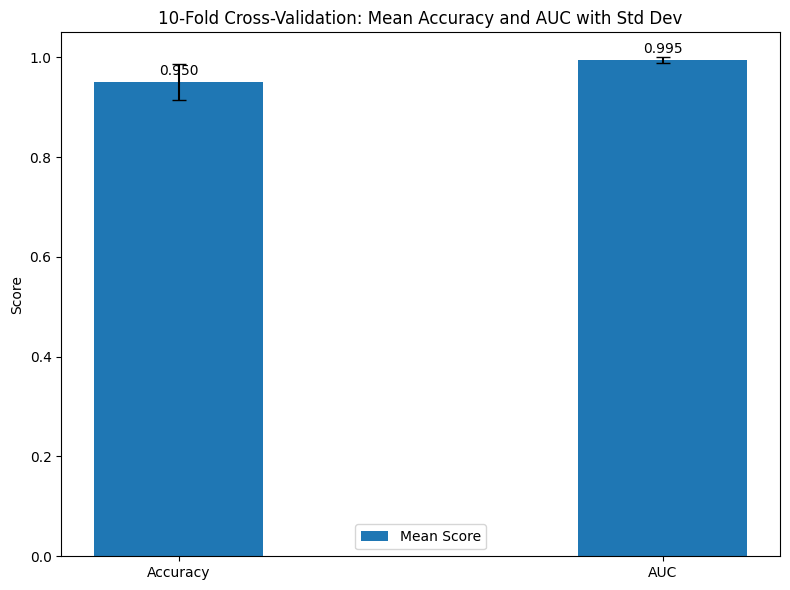

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'AUC']
means = [cv_results['accuracy_mean'], cv_results['auc_mean']]
stds = [cv_results['accuracy_std'], cv_results['auc_std']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x, means, width, yerr=stds, capsize=5, label='Mean Score')

ax.set_ylabel('Score')
ax.set_title('10-Fold Cross-Validation: Mean Accuracy and AUC with Std Dev')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0.0, 1.05) # Scores are between 0 and 1

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)

plt.tight_layout()
plt.show()

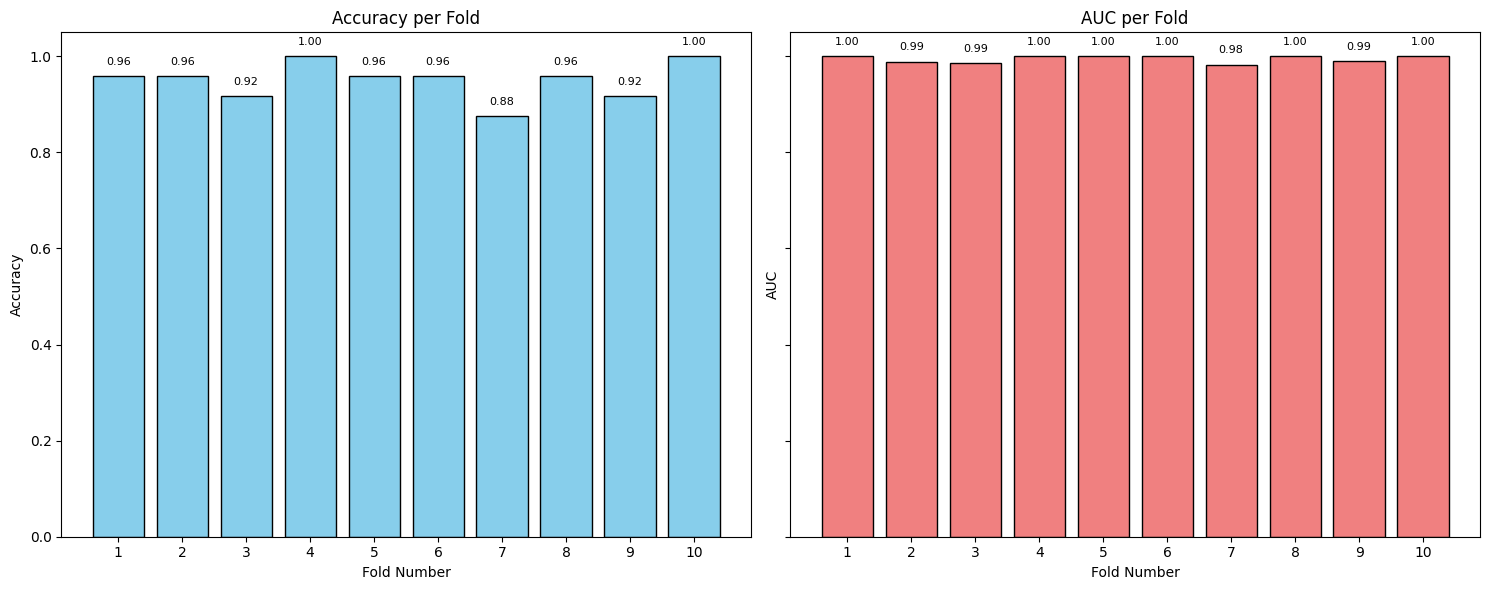

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

accuracies_per_fold = cv_results['accuracies_per_fold']
aucs_per_fold = cv_results['aucs_per_fold']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plot Accuracies per fold
ax1.bar(range(1, len(accuracies_per_fold) + 1), accuracies_per_fold, color='skyblue', edgecolor='black')
ax1.set_title('Accuracy per Fold')
ax1.set_xlabel('Fold Number')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(range(1, len(accuracies_per_fold) + 1))
ax1.set_ylim(0, 1.05)
for i, val in enumerate(accuracies_per_fold):
    ax1.text(i + 1, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

# Plot AUCs per fold
ax2.bar(range(1, len(aucs_per_fold) + 1), aucs_per_fold, color='lightcoral', edgecolor='black')
ax2.set_title('AUC per Fold')
ax2.set_xlabel('Fold Number')
ax2.set_ylabel('AUC')
ax2.set_xticks(range(1, len(aucs_per_fold) + 1))
ax2.set_ylim(0, 1.05)
for i, val in enumerate(aucs_per_fold):
    ax2.text(i + 1, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
final_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=best_C,
        max_iter=5000
    ))
])

final_logistic_model.fit(X_train, y_train)
print("Final model trained with best C on training data.")

Final model trained with best C on training data.


In [ ]:
#test the model
#TEST EVALUATION
y_prob_test = final_logistic_model.predict_proba(X_test)
test_auc = roc_auc_score(y_test, y_prob_test, multi_class="ovr")
print("Test AUC:", test_auc)
test_acc = accuracy_score(y_test, final_logistic_model.predict(X_test))
print("Test Accuracy:", test_acc)
#classifcation report
from sklearn.metrics import classification_report
y_pred = final_logistic_model.predict(X_test)
print(classification_report(y_test, y_pred))



Test AUC: 0.999318607579387
Test Accuracy: 0.9571428571428572
              precision    recall  f1-score   support

     Brahman       0.94      0.94      0.94        16
         Gir       0.92      1.00      0.96        12
    Hereford       1.00      1.00      1.00         4
    Holstein       1.00      1.00      1.00         9
      Jersey       1.00      1.00      1.00         3
      Nelore       1.00      1.00      1.00        12
      Ongole       1.00      1.00      1.00         4
     Sahiwal       1.00      0.86      0.92         7
   Tharpakar       0.67      0.67      0.67         3

    accuracy                           0.96        70
   macro avg       0.95      0.94      0.94        70
weighted avg       0.96      0.96      0.96        70



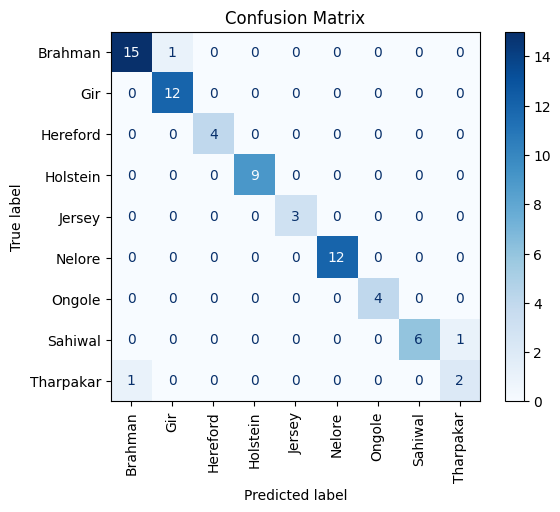

In [ ]:
#confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

# Define class_names using the keys from label_mapping_raw
class_names = list(label_mapping_raw.keys())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")

# Rotate x-axis labels
disp.ax_.tick_params(axis='x', rotation=90)

plt.title("Confusion Matrix")
plt.show()

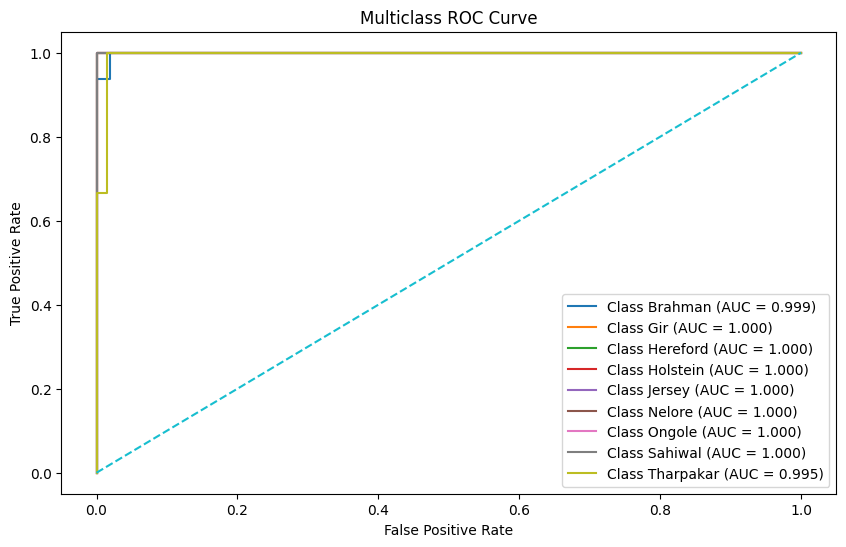

In [ ]:
#ROC-AUC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=[10,6]) # Reverted to default figure size

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_test[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend() # Reverted to default legend positioning
# Removed plt.tight_layout() as it's often used with external legends
plt.show()

The number of selected features is:
816


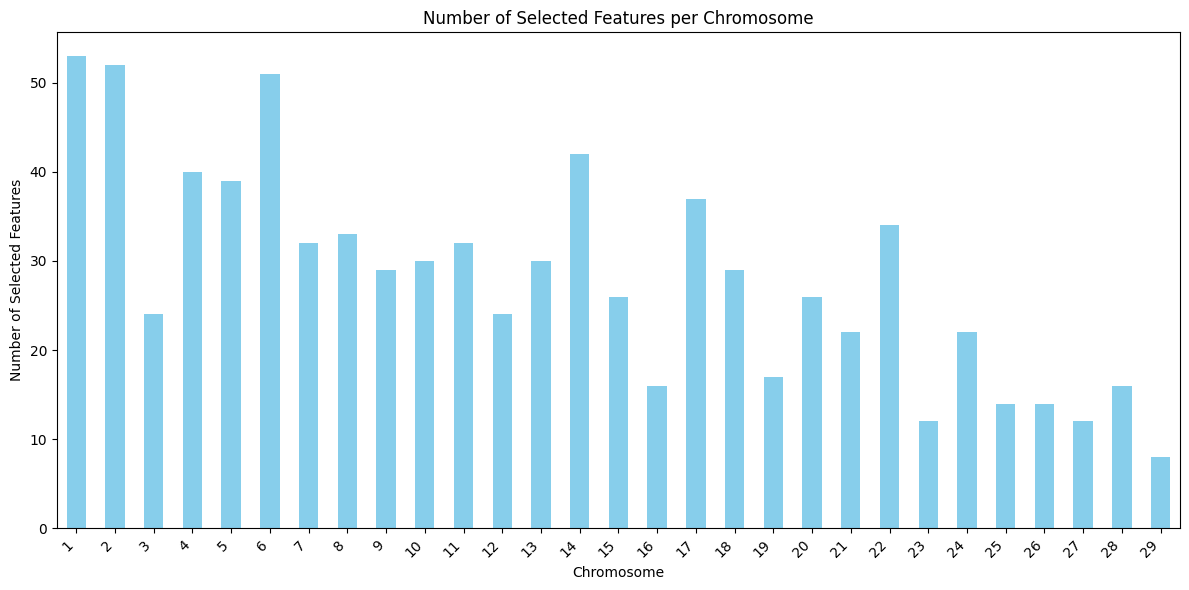

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Re-define selected_feature_names (originally from cell 8e272ba5)
logistic_model = final_logistic_model.named_steps['clf']
coefficients = logistic_model.coef_
selected_features_mask = (coefficients != 0).any(axis=0)
selected_feature_names = X_train.columns[selected_features_mask]
print("The number of selected features is:")
print(len(selected_feature_names))
# Extract chromosome number from feature names
# Feature names are in the format 'chr:pos_nucleotide'
chromosomes = [feature.split(':')[0] for feature in selected_feature_names]

# Count the occurrences of each chromosome
chromosome_counts = pd.Series(chromosomes).value_counts()

# Convert the index (chromosome names) to integers for numerical sorting
# This assumes all chromosome names can be converted to integers. If there were
# non-numeric chromosomes (e.g., 'X', 'Y'), more complex handling would be needed.
chromosome_counts.index = chromosome_counts.index.map(int)

# Sort the series by its numeric index
chromosome_counts = chromosome_counts.sort_index()

# Create the bar plot
plt.figure(figsize=(12, 6))
chromosome_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Selected Features per Chromosome')
plt.xlabel('Chromosome')
plt.ylabel('Number of Selected Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

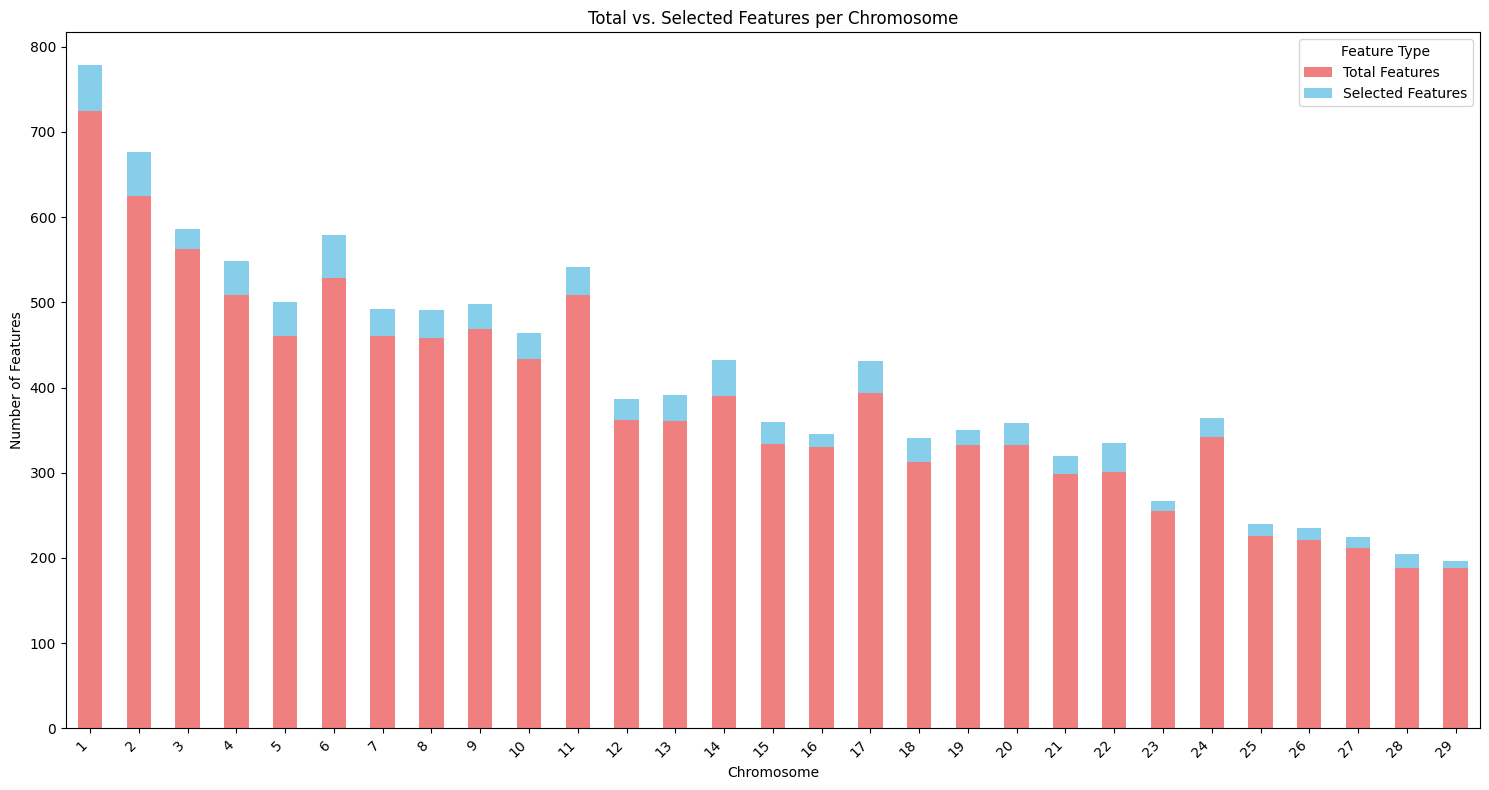

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get total features per chromosome from the original input X
all_chromosomes = [col.split(':')[0] for col in X.columns]
all_feature_counts = pd.Series(all_chromosomes).value_counts()
all_feature_counts.index = all_feature_counts.index.map(int)
all_feature_counts = all_feature_counts.sort_index()

# 2. Prepare selected feature counts (already have chromosome_counts from previous step)
# Ensure both series have the same index for alignment

# 3. Combine into a single DataFrame for stacked plotting
plot_df = pd.DataFrame({
    'Total Features': all_feature_counts,
    'Selected Features': chromosome_counts
}).fillna(0) # Fill NaN with 0 if a chromosome has no selected features

# 4. Create the stacked bar plot
plt.figure(figsize=(15, 8))
plot_df.plot(kind='bar', stacked=True, color=['lightcoral', 'skyblue'], ax=plt.gca())

plt.title('Total vs. Selected Features per Chromosome')
plt.xlabel('Chromosome')
plt.ylabel('Number of Features')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Feature Type')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Ensure all_feature_counts and chromosome_counts are aligned
combined_counts = pd.DataFrame({
    'Total Features': all_feature_counts,
    'Selected Features': chromosome_counts
}).fillna(0)

# Calculate the percentage of selected features
combined_counts['Percentage Selected'] = (combined_counts['Selected Features'] / combined_counts['Total Features']) * 100

# Sort by percentage in descending order and get the top 5
top_5_chromosomes = combined_counts.sort_values(by='Percentage Selected', ascending=False).head(5)

print("Top 5 Chromosomes with Highest Percentage of Selected Features:")
display(top_5_chromosomes)

#also the lowest ones
last_5_chromosomes = combined_counts.sort_values(by='Percentage Selected', ascending=True).head(5)

print("Last 5 Chromosomes with Lowest Percentage of Selected Features:")
display(last_5_chromosomes)

Top 5 Chromosomes with Highest Percentage of Selected Features:


,Total Features,Selected Features,Percentage Selected
22,301,34,11.295681
14,390,42,10.769231
6,528,51,9.659091
17,394,37,9.390863
18,312,29,9.294872


Last 5 Chromosomes with Lowest Percentage of Selected Features:


,Total Features,Selected Features,Percentage Selected
29,188,8,4.255319
3,562,24,4.270463
23,255,12,4.705882
16,330,16,4.848485
19,333,17,5.105105
